# Data sampling with a sliding window

We train LLMs to generate one word at a time, so we want to prepare the training data accordingly where the next word in a sequence represents the target to predict:

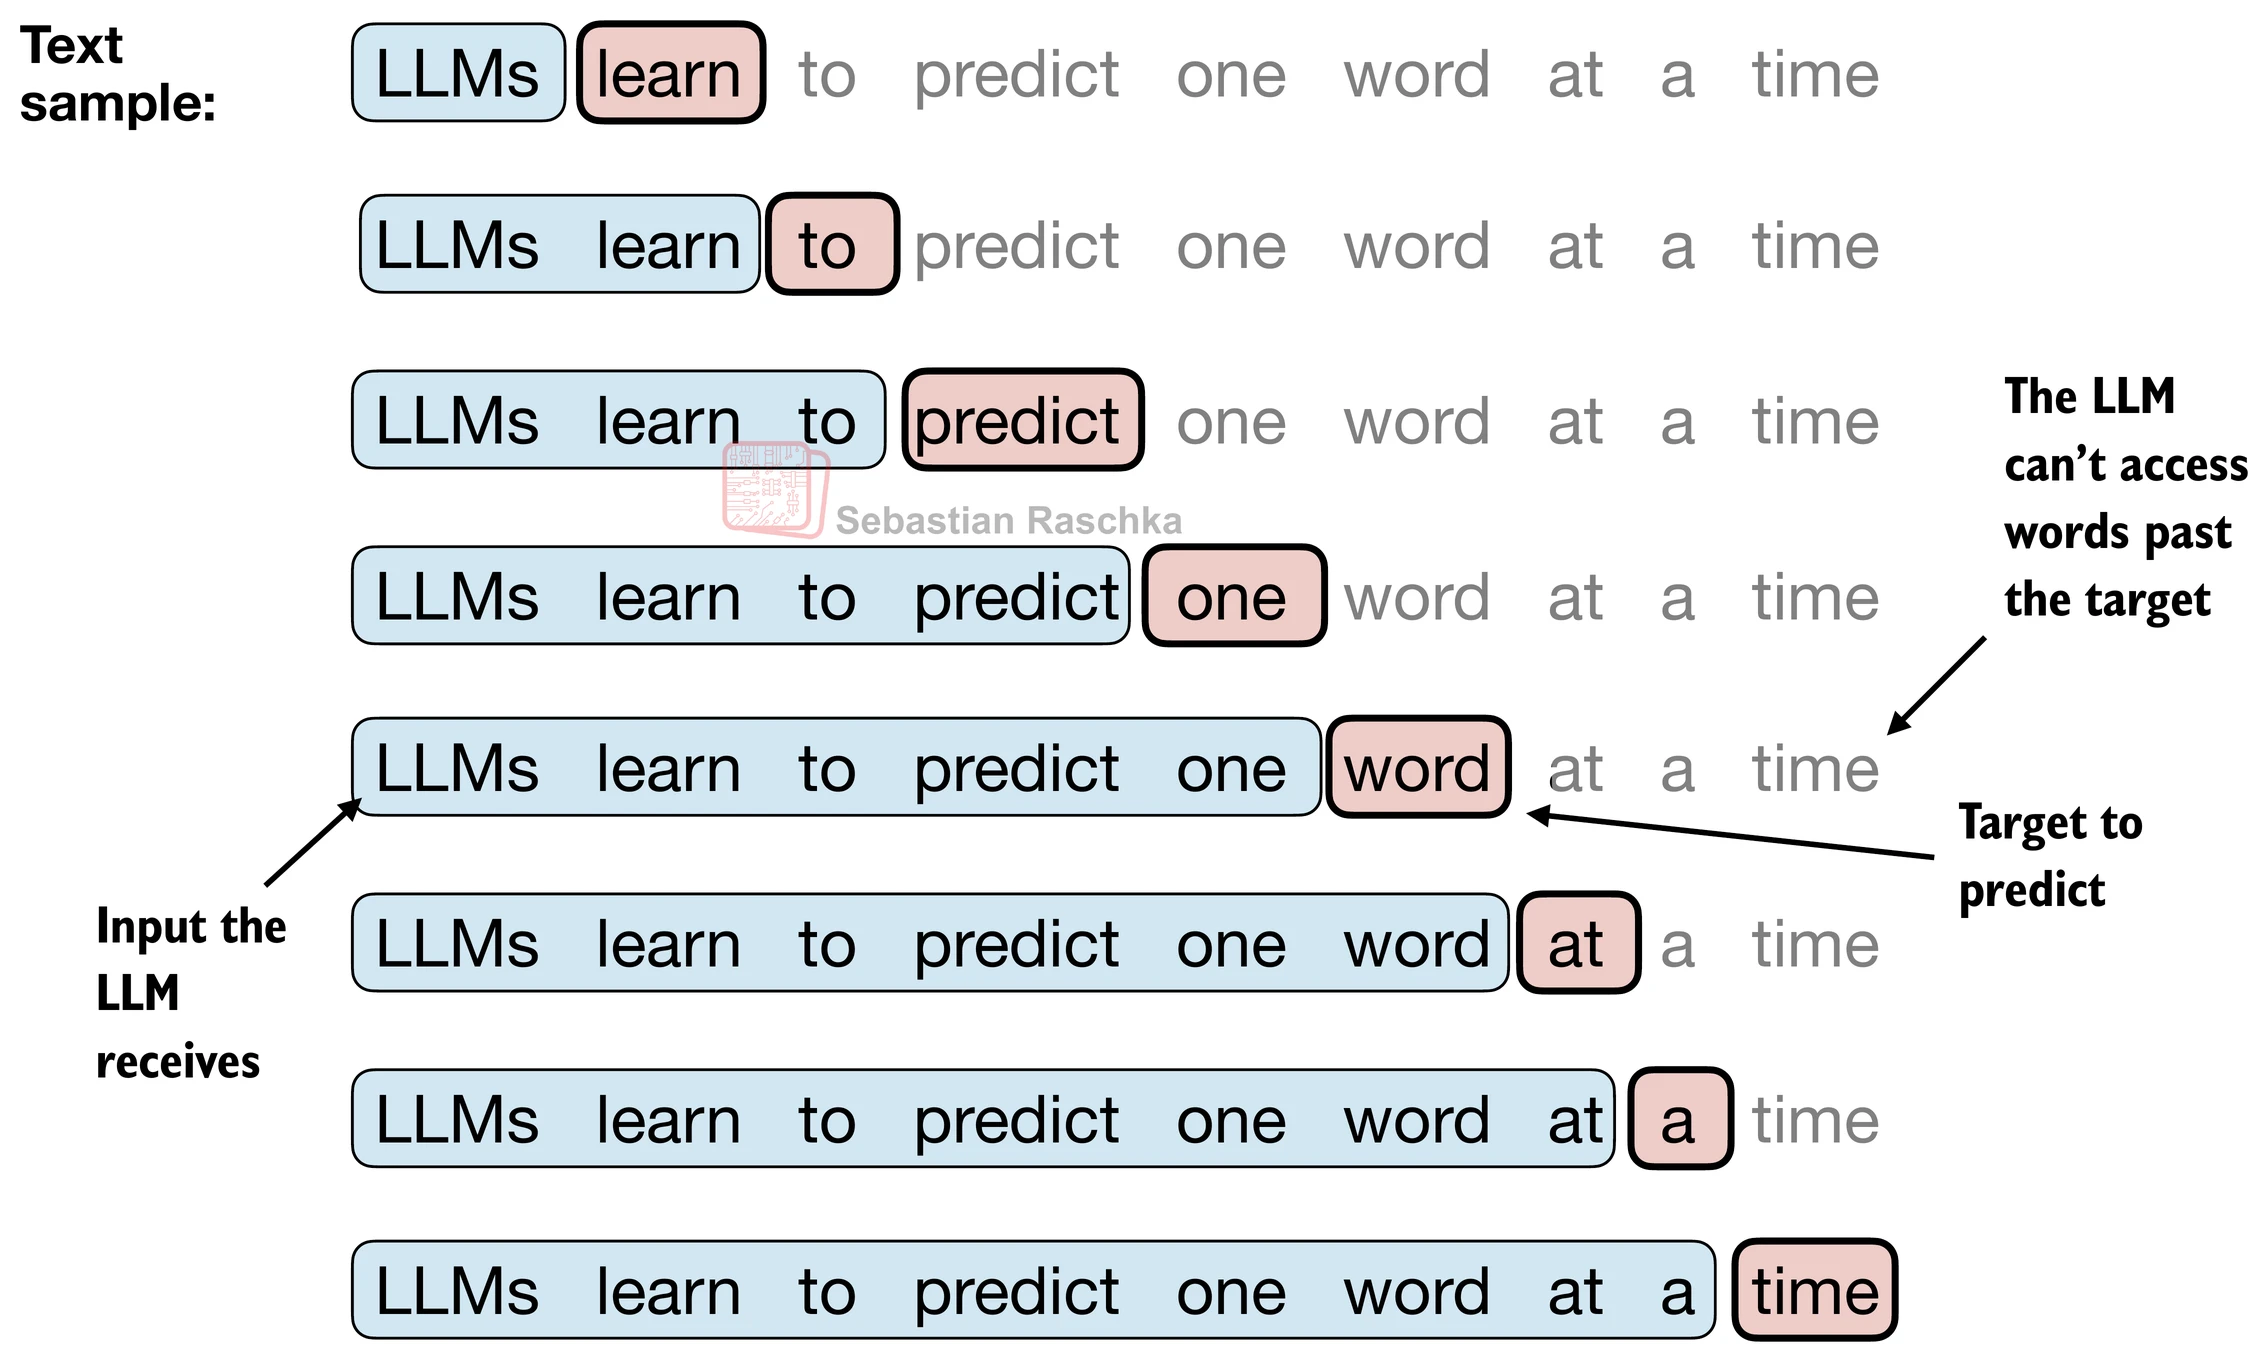

1. Autoregressive
2. Self supervised learning (In pre training stage, the model learns by predicting the next token (word) in a sequence, using vast amounts of unlabeled text data where the context acts as its own label.)

In [1]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

with open("../data/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


1. For each text chunk, we want the inputs and targets
2. Since we want the model to predict the next word, the targets are the inputs shifted by one position to the right

In [2]:
## removing initial 50 tokens so that passage becomes more interesting
enc_sample = enc_text[50:]

In [3]:
context_size = 4 ## How many tokens do we want to use as input to predict the next token?

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [4]:
for i in range(1,context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(f"Context: {context} --> Desired: {desired}")

Context: [290] --> Desired: 4920
Context: [290, 4920] --> Desired: 2241
Context: [290, 4920, 2241] --> Desired: 287
Context: [290, 4920, 2241, 287] --> Desired: 257


In [5]:

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


we implement a simple data loader that iterates over the input dataset and returns the inputs and targets shifted by one

## Implement a Data Loader

We will implement a data loader that fetches input output target pairs using a sliding window approach

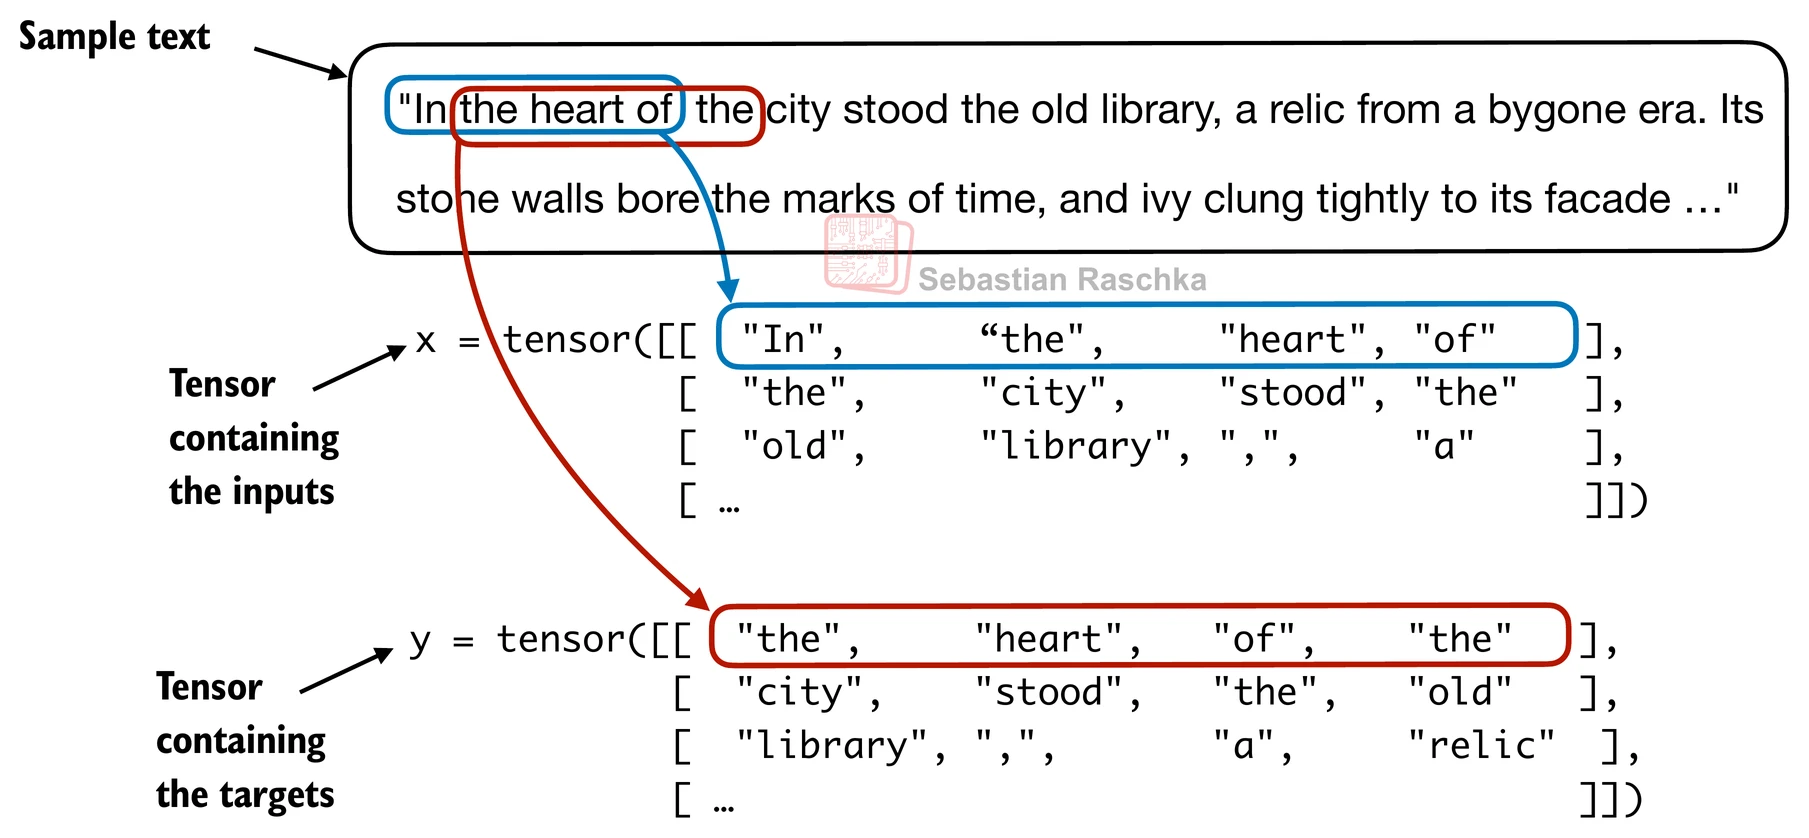

1. We collect inputs in a tensor x where each row represents one input context.
2. The second tensor y contains the corresponding prediction targets (next words) which are created by shifting the input by one position.

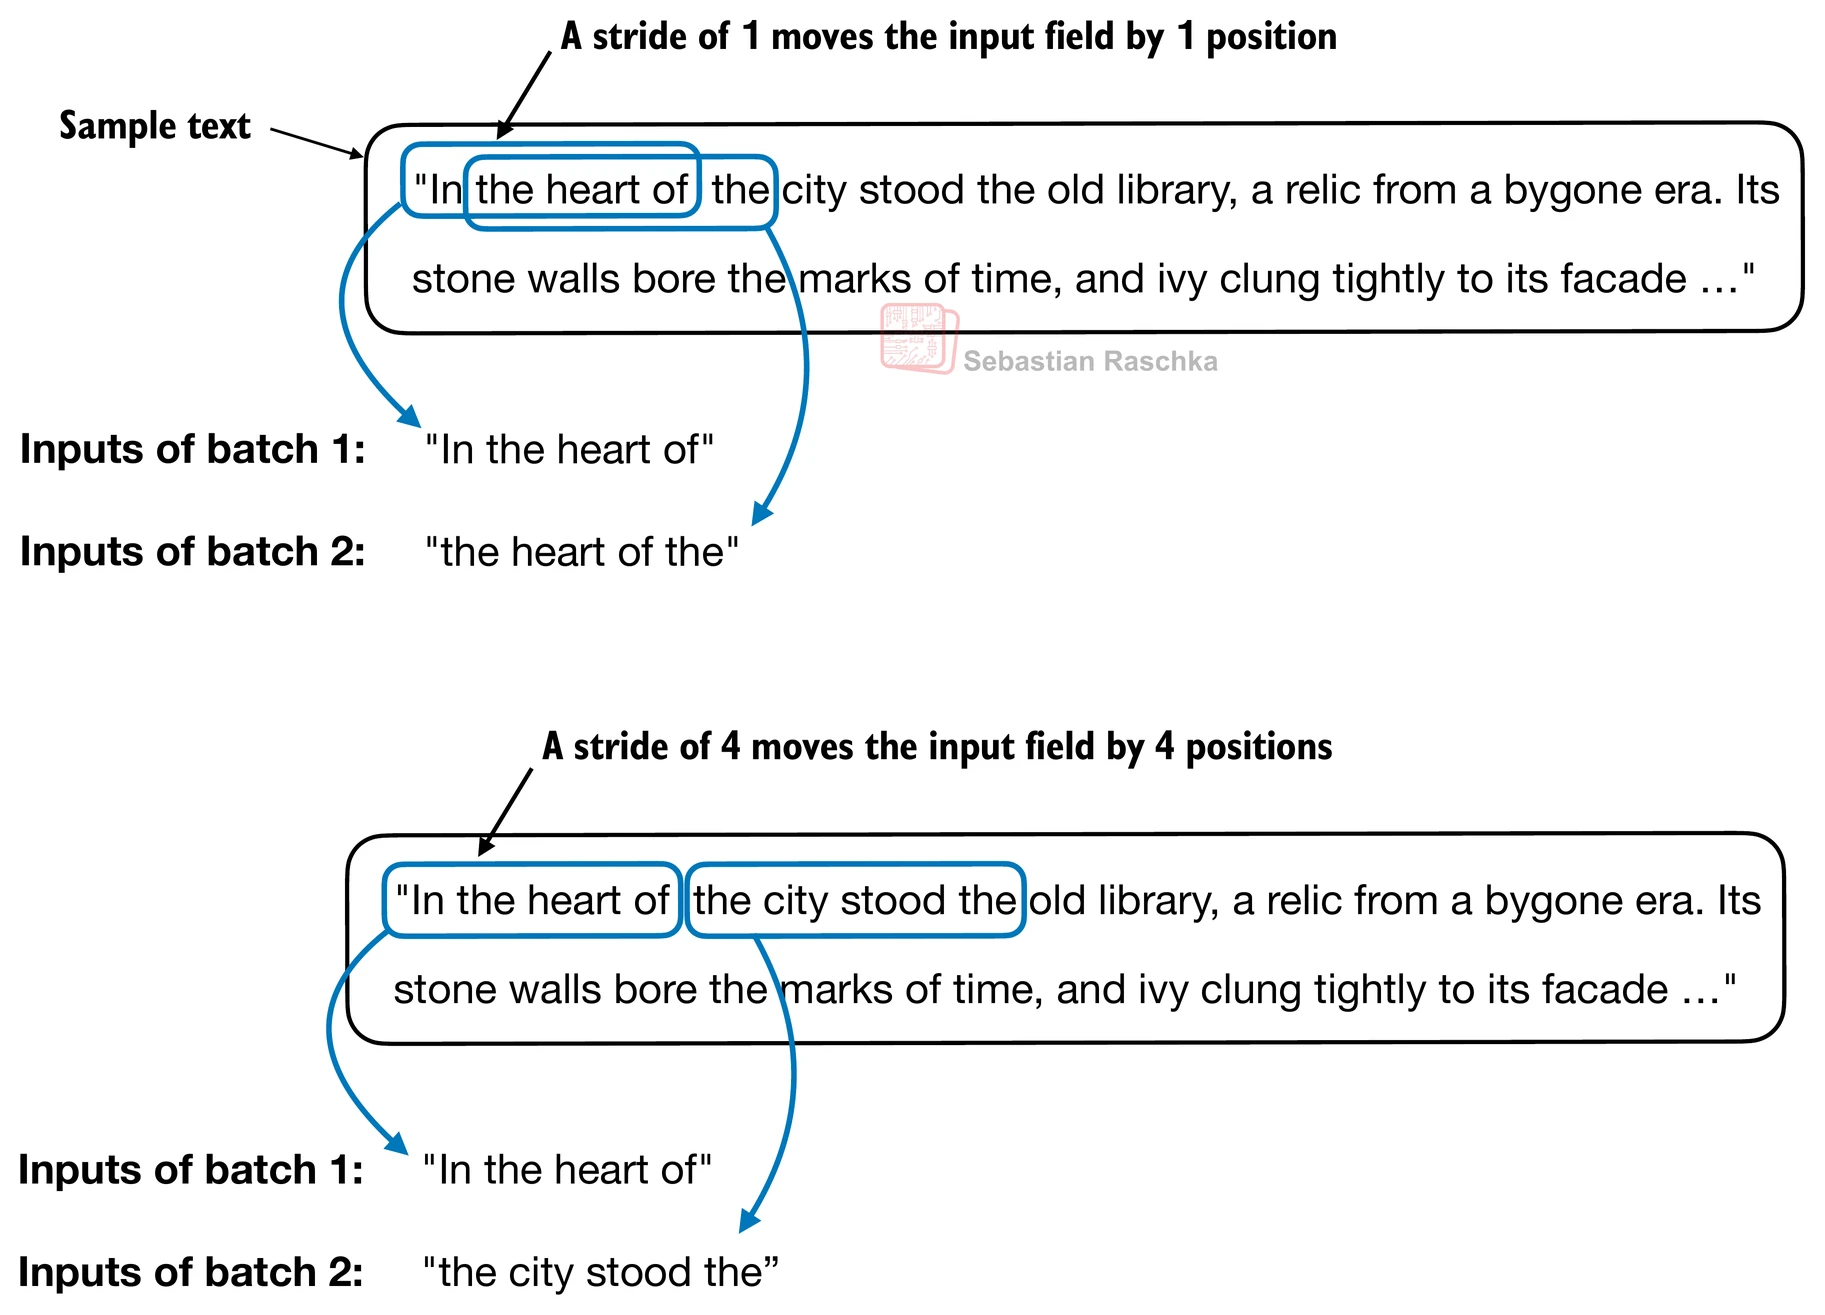

In [6]:
# pip install torch
from torch.utils.data import Dataset, DataLoader

/Users/sanjaygudla/Documents/LLM/.venv/lib/python3.11/site-packages/torch/_subclasses/functional_tensor.py:283: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


In [7]:
import torch


## It defines how individual rows are fetched from the dataset.
## each row consisits of a number of token IDs (based on max_length) assigned to an input_chunk tensor.
## the target_chunk tensor contains the corresponding targets.

class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids=[]
        
        # Tokenize the entire text
        token_ids = tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
        
        # Use a sliding window to chunk the book into overalpping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
            
    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

1. Initialize the tokenizer.
2. Create dataset
3. drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training
4. The number of CPU processes to use for preprocessing

In [8]:
## batch_size: Number of batches the model processes before updating weights. Larger batch sizes can lead to faster training but require more memory. Common values are 16, 32, 64, etc.
## max_length: How many tokens in each input sequence. Longer means more context but more memory usage. (Context Size)
## stride: How much to shift the sliding window for creating the next sequence. Smaller means more overlap between sequences but more total sequences. (Overlap Size)
## num_workers: Number of subprocesses to use for data loading. 0 means the data will be loaded in the main process. Higher values can speed up data loading but may cause issues on some platforms.

def create_dataloader_v1(txt,batch_size=4,max_length = 256,
                         stride=128,shuffle=True,drop_last=True,
                         num_workers=0):
    
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")
    
    # Create the dataset
    dataset = GPTDatasetV1(txt,tokenizer,max_length,stride)
    
    # Create the dataloader
    # DataLoader will check __getitem__ of the dataset to fetch individual rows and collate them into batches.
    dataloader = DataLoader(dataset, 
                            batch_size=batch_size, 
                            shuffle=shuffle, 
                            drop_last=drop_last, 
                            num_workers=num_workers
                            )
    
    return dataloader

## This dataloader will yield batches of input and target tensors that can be fed into a language model for training. Each batch will contain sequences of token IDs, where the input tensor contains the context and the target tensor contains the next token to predict.



In [9]:
with open("../data/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [10]:
import torch
print("PyTorch version:", torch.__version__)
dataloader = create_dataloader_v1(raw_text, batch_size=1, 
                                  max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)


PyTorch version: 2.10.0
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


## Note : 

1. max_length(context_length) - The above small context size of 4 is just for illustartion, generally it is common to train LLms with input sizes of atleast 256

2. batch_size - batch_size=1 is just for illustartion purposes. Small batch_sizes required less memory during training but lead to more noisy updates. This is a hyperparameter to exeriment with when training LLMS

3. stride - If stride=1, there can be chance of overfitting because the same input repeats again and again. So generally peopel use stride=context_length so that there is no overlap and also no missing data

In [11]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])
